# Text-Based One-Hot Encoding — Statistical Leakage Detection, Clean Export & Comparison

**Tujuan:**  
Mengganti filter leakage hardcoded (`LEAKY_KEYWORDS` = 8 kata) dengan pendekatan **data-driven** yang memindai SELURUH 463 atribut secara statistik, lalu membandingkan performa text-based vs CNN.

**Workflow:**  
1. Scan SELURUH 463 atribut: hitung category concentration (dominance %)  
2. Flag atribut dengan dominance > 70% sebagai LEAKY  
3. Build TWO sets of profiles: **unfiltered** (original) dan **filtered** (clean)  
4. Simpan vector space ke `.npy` — **TANPA** mengubah `list_attr_all.csv` asli  
5. Evaluasi & bandingkan: One-Hot (unfiltered vs filtered) vs 4 CNN Exp3 models  
6. Dua protokol evaluasi: Recommender Simulation + Category-Level Retrieval

---
## Cell 1: Import & Konfigurasi

In [1]:
import os, re, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MultiLabelBinarizer
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── Cross-Platform Path ─────────────────────────────────────────────
if platform.system() == 'Linux' and os.path.exists('/mnt/d'):
    BASE_DIR = '/mnt/d/Antigravity/Visual Based Rekomender Sistem'
else:
    BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))

DATASET_DIR = os.path.join(BASE_DIR, 'dataset')
ANNO_DIR    = os.path.join(DATASET_DIR, 'In-shop Clothes Retrieval Benchmark', 'Anno')
ATTR_DIR    = os.path.join(ANNO_DIR, 'attributes')
FEAT_DIR    = os.path.join(BASE_DIR, 'features', 'exp3_partial_unfreeze')
EVAL_DIR    = os.path.join(BASE_DIR, 'baseline_text_cbf', 'evaluation')
os.makedirs(EVAL_DIR, exist_ok=True)

# ── Threshold & Eval Config ─────────────────────────────────────────
DOMINANCE_THRESHOLD = 0.70
K_VALUES = [5, 10, 20]
N_USERS  = 100
N_LIKED  = 3
RANDOM_SEED = 42

print(f'BASE_DIR : {BASE_DIR}')
print(f'FEAT_DIR : {FEAT_DIR}')
print(f'EVAL_DIR : {EVAL_DIR}')
print(f'Threshold: {DOMINANCE_THRESHOLD:.0%}')
print('OK')

BASE_DIR : /mnt/d/Antigravity/Visual Based Rekomender Sistem
FEAT_DIR : /mnt/d/Antigravity/Visual Based Rekomender Sistem/features/exp3_partial_unfreeze
EVAL_DIR : /mnt/d/Antigravity/Visual Based Rekomender Sistem/baseline_text_cbf/evaluation
Threshold: 70%
OK


---
## Cell 2: Load Raw Data

In [2]:
# ── 2a. Master Dataset ──────────────────────────────────────────────
df_master = pd.read_csv(os.path.join(DATASET_DIR, 'master_dataset.csv'))
df_items = df_master.drop_duplicates(subset='item_id')[['item_id','category','gender','clothes_type_label']].reset_index(drop=True)
item_to_cat = dict(zip(df_items['item_id'], df_items['category']))

cat_counts = df_items['category'].value_counts()
valid_cats = cat_counts[cat_counts >= 20].index.tolist()
df_items_f = df_items[df_items['category'].isin(valid_cats)].reset_index(drop=True)

print(f'Unique items: {len(df_items):,}')
print(f'Categories (>=20): {len(valid_cats)}')
print(f'Items after filter: {len(df_items_f):,}')
df_items['category'].value_counts().to_frame()

Unique items: 7,975
Categories (>=20): 16
Items after filter: 7,975


,count
category,
Tees_Tanks,1710
Blouses_Shirts,1429
Dresses,1271
Shorts,597
Sweaters,510
Pants,421
Jackets_Coats,359
Rompers_Jumpsuits,327
Skirts,287


In [3]:
# ── 2b. 463 Attribute Names ─────────────────────────────────────────
attr_names = []
with open(os.path.join(ATTR_DIR, 'list_attr_cloth.txt')) as f:
    f.readline(); f.readline()
    for line in f:
        if line.strip():
            attr_names.append(line.strip().split()[0])
print(f'Attributes: {len(attr_names)}')
print(f'First 20: {attr_names[:20]}')

Attributes: 463
First 20: ['lightweight', 'polyester', 'woven', 'knit', 'cotton', 'unlined', 'rayon', 'spandex', 'top', 'print', 'pockets', 'dress', 'classic', 'lined', 'fit', 'round', 'love', 'elasticized', 'tee', 'trim']


In [4]:
# ── 2c. Binary Attribute Labels ────────────────────────────────────
item_attr_binary = {}
with open(os.path.join(ATTR_DIR, 'list_attr_items.txt')) as f:
    f.readline(); f.readline()
    for line in f:
        parts = line.strip().split()
        if len(parts) < 2: continue
        item_attr_binary[parts[0]] = {i for i, v in enumerate(parts[1:]) if int(v) == 1}
print(f'Items with attributes: {len(item_attr_binary):,}')

Items with attributes: 7,982


In [5]:
# ── 2d. Color Information ───────────────────────────────────────────
item_colors = defaultdict(set)
with open(os.path.join(ATTR_DIR, 'list_color_cloth.txt')) as f:
    f.readline(); f.readline()
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            m = re.search(r'(id_\d+)', parts[0])
            if m: item_colors[m.group(1)].add(parts[1].lower().replace('-','_'))
item_colors = {k: sorted(v) for k, v in item_colors.items()}
print(f'Items with color: {len(item_colors):,}')

Items with color: 7,982


---
## Cell 3: Statistical Leakage Detection — ALL 463 Attributes

In [6]:
leakage_report = []
for attr_idx, attr_name in enumerate(attr_names):
    active_items = [iid for iid, aset in item_attr_binary.items() if attr_idx in aset]
    n_active = len(active_items)
    if n_active == 0:
        leakage_report.append({'attr_index': attr_idx, 'attr_name': attr_name,
            'n_active_items': 0, 'dominant_category': 'N/A', 'dominance_pct': 0.0,
            'n_categories': 0, 'verdict': 'NO_DATA', 'top3_categories': ''})
        continue
    cc = defaultdict(int)
    for iid in active_items: cc[item_to_cat.get(iid,'UNKNOWN')] += 1
    sc = sorted(cc.items(), key=lambda x: -x[1])
    dom_cat, dom_cnt = sc[0]
    dom_pct = dom_cnt / n_active
    top3 = ', '.join(f'{c}: {n} ({n/n_active:.1%})' for c, n in sc[:3])
    if dom_pct > 0.90: verdict = 'JELAS_LEAKAGE'
    elif dom_pct > DOMINANCE_THRESHOLD: verdict = 'STRONG_LEAKAGE'
    elif dom_pct > 0.50: verdict = 'PARTIAL'
    else: verdict = 'AMAN'
    leakage_report.append({'attr_index': attr_idx, 'attr_name': attr_name,
        'n_active_items': n_active, 'dominant_category': dom_cat,
        'dominance_pct': round(dom_pct, 4), 'n_categories': len(sc),
        'verdict': verdict, 'top3_categories': top3})

df_report = pd.DataFrame(leakage_report).sort_values('dominance_pct', ascending=False).reset_index(drop=True)
leaky_df = df_report[df_report['verdict'].isin(['JELAS_LEAKAGE','STRONG_LEAKAGE'])].copy()
leaky_indices = set(leaky_df['attr_index'].tolist())

print('='*80)
print('  STATISTICAL LEAKAGE SCAN — ALL 463 ATTRIBUTES')
print('='*80)
print(f'\n  Verdict Distribution:')
print(df_report['verdict'].value_counts().to_string())
print(f'\n  LEAKY (>{DOMINANCE_THRESHOLD:.0%}): {len(leaky_indices)}')
print(f'  SAFE: {len(attr_names) - len(leaky_indices)}')
print(f'\n  Top-15 Leaky:')
for i,(_, r) in enumerate(leaky_df.head(15).iterrows(),1):
    print(f'    {i:>2}. {r["attr_name"]:<20} {r["dominance_pct"]:.1%} -> {r["dominant_category"]}')
df_report.head(20)

  STATISTICAL LEAKAGE SCAN — ALL 463 ATTRIBUTES

  Verdict Distribution:
verdict
AMAN              307
NO_DATA           116
PARTIAL            27
STRONG_LEAKAGE      9
JELAS_LEAKAGE       4

  LEAKY (>70%): 13
  SAFE: 450

  Top-15 Leaky:
     1. light                100.0% -> Dresses
     2. jumpsuit             100.0% -> Rompers_Jumpsuits
     3. romper               97.3% -> Rompers_Jumpsuits
     4. sweatpants           95.7% -> Pants
     5. bodycon              81.0% -> Dresses
     6. sweatshirt           79.1% -> Sweatshirts_Hoodies
     7. notched              78.1% -> Jackets_Coats
     8. shorts               78.0% -> Shorts
     9. peasant              77.1% -> Blouses_Shirts
    10. pants                76.7% -> Pants
    11. blouse               76.3% -> Blouses_Shirts
    12. hoodie               74.8% -> Sweatshirts_Hoodies
    13. dress                70.6% -> Dresses


,attr_index,attr_name,n_active_items,dominant_category,dominance_pct,n_categories,verdict,top3_categories
0,279,light,1,Dresses,1.0000,1,JELAS_LEAKAGE,Dresses: 1 (100.0%)
1,262,jumpsuit,130,Rompers_Jumpsuits,1.0000,1,JELAS_LEAKAGE,Rompers_Jumpsuits: 130 (100.0%)
2,165,romper,183,Rompers_Jumpsuits,0.9727,4,JELAS_LEAKAGE,"Rompers_Jumpsuits: 178 (97.3%), Jackets_Coats:..."
3,309,sweatpants,92,Pants,0.9565,3,JELAS_LEAKAGE,"Pants: 88 (95.7%), Denim: 2 (2.2%), Tees_Tanks..."
4,221,bodycon,137,Dresses,0.8102,7,STRONG_LEAKAGE,"Dresses: 111 (81.0%), Skirts: 14 (10.2%), Tees..."
5,203,sweatshirt,163,Sweatshirts_Hoodies,0.7914,10,STRONG_LEAKAGE,"Sweatshirts_Hoodies: 129 (79.1%), Sweaters: 11..."
6,253,notched,128,Jackets_Coats,0.7812,9,STRONG_LEAKAGE,"Jackets_Coats: 100 (78.1%), Blouses_Shirts: 6 ..."
7,28,shorts,677,Shorts,0.7799,13,STRONG_LEAKAGE,"Shorts: 528 (78.0%), Tees_Tanks: 55 (8.1%), Bl..."
8,240,peasant,144,Blouses_Shirts,0.7708,6,STRONG_LEAKAGE,"Blouses_Shirts: 111 (77.1%), Dresses: 27 (18.8..."
9,118,pants,343,Pants,0.7668,14,STRONG_LEAKAGE,"Pants: 263 (76.7%), Blouses_Shirts: 25 (7.3%),..."


---
## Cell 4: Visualisasi Leakage

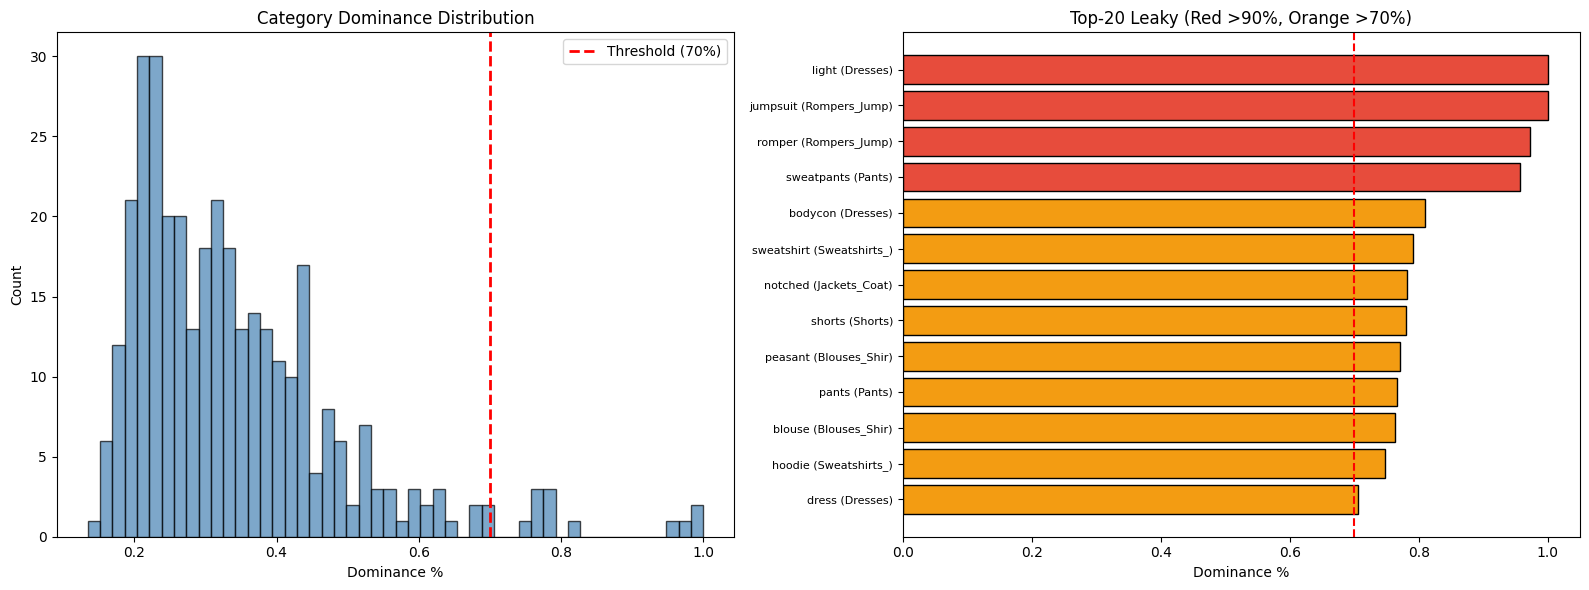

Saved: leakage_report.csv & leakage_scan_distribution.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax1 = axes[0]
valid = df_report[df_report['dominance_pct'] > 0]['dominance_pct']
ax1.hist(valid, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(DOMINANCE_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold ({DOMINANCE_THRESHOLD:.0%})')
ax1.set_xlabel('Dominance %'); ax1.set_ylabel('Count'); ax1.set_title('Category Dominance Distribution'); ax1.legend()

ax2 = axes[1]
tl = df_report[df_report['dominance_pct'] > DOMINANCE_THRESHOLD].head(20)
colors = ['#e74c3c' if v > 0.9 else '#f39c12' for v in tl['dominance_pct']]
ax2.barh(range(len(tl)), tl['dominance_pct'], color=colors, edgecolor='black')
ax2.set_yticks(range(len(tl)))
ax2.set_yticklabels([f"{r['attr_name']} ({r['dominant_category'][:12]})" for _, r in tl.iterrows()], fontsize=8)
ax2.invert_yaxis(); ax2.axvline(DOMINANCE_THRESHOLD, color='red', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Dominance %'); ax2.set_title('Top-20 Leaky (Red >90%, Orange >70%)')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, 'leakage_scan_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

report_path = os.path.join(EVAL_DIR, 'leakage_report.csv')
df_report.to_csv(report_path, index=False)
print(f'Saved: leakage_report.csv & leakage_scan_distribution.png')

---
## Cell 5: Build Both Profiles (Unfiltered + Filtered)

In [8]:
safe_attr_indices = [(i, attr_names[i]) for i in range(len(attr_names)) if i not in leaky_indices]
print(f'Total: {len(attr_names)} | Leaky removed: {len(leaky_indices)} | Safe: {len(safe_attr_indices)}')

def build_profiles(attr_idx_set):
    profiles = []
    for _, row in df_items_f.iterrows():
        active = item_attr_binary.get(row['item_id'], set())
        attrs = [attr_names[i] for i in attr_idx_set if i in active]
        colors = [f'color:{c}' for c in item_colors.get(row['item_id'], [])]
        profiles.append(attrs + colors)
    return profiles

prof_unf = build_profiles(set(range(len(attr_names))))
prof_flt = build_profiles({i for i, _ in safe_attr_indices})
print(f'Unfiltered avg: {np.mean([len(p) for p in prof_unf]):.1f} features/item')
print(f'Filtered   avg: {np.mean([len(p) for p in prof_flt]):.1f} features/item')

Total: 463 | Leaky removed: 13 | Safe: 450
Unfiltered avg: 21.4 features/item
Filtered   avg: 20.9 features/item


---
## Cell 6: Build One-Hot Matrices & L2 Normalize

In [9]:
def build_onehot(profiles):
    mlb = MultiLabelBinarizer(sparse_output=False)
    mat = mlb.fit_transform(profiles).astype(np.float64)
    norms = np.linalg.norm(mat, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return mat / norms, mlb

mat_unf, mlb_u = build_onehot(prof_unf)
mat_flt, mlb_f = build_onehot(prof_flt)

item_ids   = df_items_f['item_id'].values
categories = df_items_f['category'].values

print(f'Unfiltered: {mat_unf.shape} ({mlb_u.classes_.shape[0]} features)')
print(f'Filtered  : {mat_flt.shape} ({mlb_f.classes_.shape[0]} features)')
print(f'Items     : {len(item_ids):,}')
print(f'L2 check  : unf={np.linalg.norm(mat_unf[0]):.4f}, flt={np.linalg.norm(mat_flt[0]):.4f}')

Unfiltered: (7975, 1170) (1170 features)
Filtered  : (7975, 1158) (1158 features)
Items     : 7,975
L2 check  : unf=1.0000, flt=1.0000


---
## Cell 7: Save Vector Spaces (.npy + index CSV)

In [10]:
np.save(os.path.join(EVAL_DIR, 'onehot_unfiltered_matrix.npy'), mat_unf)
np.save(os.path.join(EVAL_DIR, 'onehot_filtered_matrix.npy'), mat_flt)
pd.DataFrame({'item_id': item_ids, 'category': categories}).to_csv(
    os.path.join(EVAL_DIR, 'onehot_item_index.csv'), index=False)

print('Saved:')
print(f'  1. onehot_unfiltered_matrix.npy  {mat_unf.shape}')
print(f'  2. onehot_filtered_matrix.npy    {mat_flt.shape}')
print(f'  3. onehot_item_index.csv         {len(item_ids)} items')
print(f'\n  Original list_attr_all.csv is UNTOUCHED.')

Saved:
  1. onehot_unfiltered_matrix.npy  (7975, 1170)
  2. onehot_filtered_matrix.npy    (7975, 1158)
  3. onehot_item_index.csv         7975 items

  Original list_attr_all.csv is UNTOUCHED.


---
## Cell 7b: Representation Richness Check (Safeguard)


=== UNFILTERED — Representation Richness ===
Category                  Avg Active Attrs
───────────────────────────────────────────
Blouses_Shirts                       22.69
Cardigans                            19.28
Denim                                21.09
Dresses                              22.97
Graphic_Tees                         15.49
Jackets_Coats                        24.87
Jackets_Vests                        25.90
Leggings                             21.77
Pants                                23.17
Rompers_Jumpsuits                    24.61
Shirts_Polos                         20.11
Shorts                               20.53
Skirts                               21.38
Sweaters                             20.09
Sweatshirts_Hoodies                  20.38
Tees_Tanks                           19.30
───────────────────────────────────────────
Mean                                 21.48
Std                                   2.57
CV (target < 0.3)                    0.120

✓ All

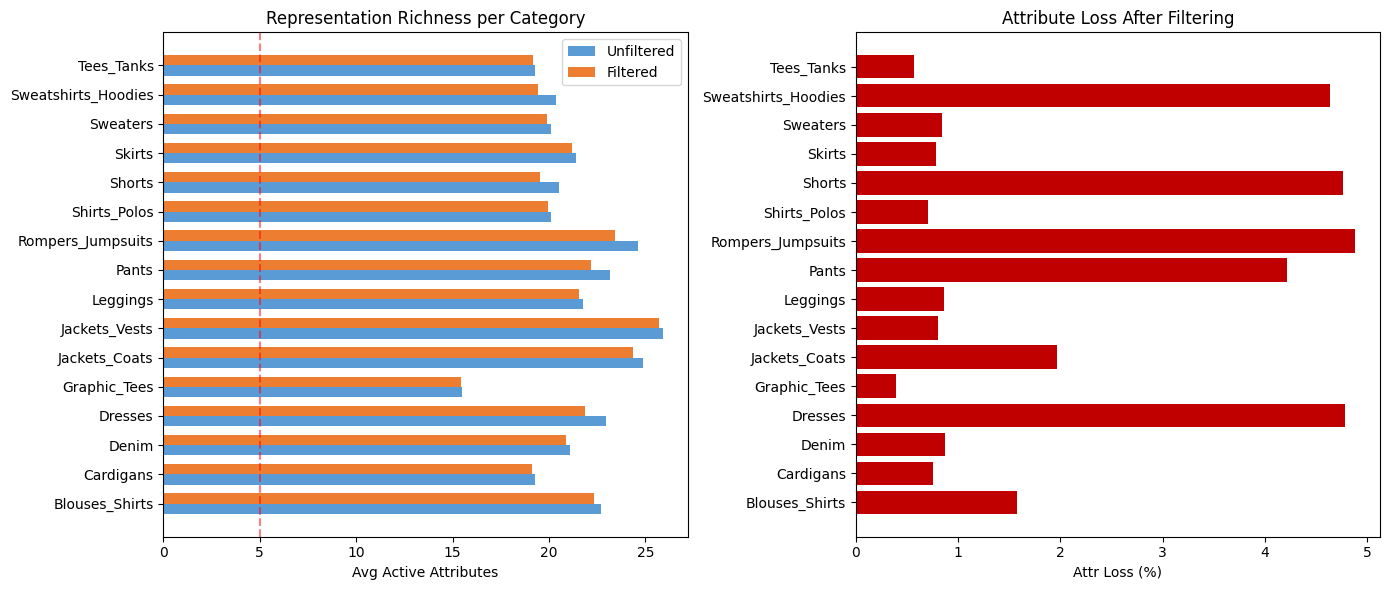


Saved: representation_richness.png


In [20]:
# ── Representation Richness Check ────────────────────────────────────
# Safeguard: ensures no category collapses after filtering.
# Measures average active attributes per item, per category.
# CV (coefficient of variation) should stay < 0.3 for balanced representation.

def representation_richness(profiles, categories, label='Profile'):
    active_counts = np.array([len(p) for p in profiles])
    df_r = pd.DataFrame({'category': categories, 'n_active': active_counts})
    mean_per_cat = df_r.groupby('category')['n_active'].mean()
    cv = mean_per_cat.std() / mean_per_cat.mean()
    print(f'\n=== {label} — Representation Richness ===')
    print(f'{"Category":<25} {"Avg Active Attrs":>16}')
    print('\u2500' * 43)
    for cat in sorted(mean_per_cat.index):
        val = mean_per_cat[cat]
        flag = ' \u26a0 COLLAPSE RISK' if val < 5.0 else ''
        print(f'{cat:<25} {val:>16.2f}{flag}')
    print('\u2500' * 43)
    print(f'{"Mean":<25} {mean_per_cat.mean():>16.2f}')
    print(f'{"Std":<25} {mean_per_cat.std():>16.2f}')
    print(f'{"CV (target < 0.3)":<25} {cv:>16.3f}')
    collapsed = mean_per_cat[mean_per_cat < 5.0]
    if len(collapsed) > 0:
        print(f'\n\u26a0 WARNING: {len(collapsed)} category(s) have < 5 avg active attrs:')
        for cat, val in collapsed.items():
            print(f'  - {cat}: {val:.2f}')
    else:
        print(f'\n\u2713 All categories have \u2265 5 avg active attributes.')
    return mean_per_cat, cv

rich_unf, cv_unf = representation_richness(prof_unf, categories, 'UNFILTERED')
rich_flt, cv_flt = representation_richness(prof_flt, categories, 'FILTERED')

# ── Comparison ────────────────────────────────────────────────────────
print(f'\n=== Filtered vs Unfiltered \u2014 Attr Loss per Category ===')
print(f'{"Category":<25} {"Unfiltered":>12} {"Filtered":>12} {"Loss":>8}')
print('\u2500' * 59)
for cat in sorted(rich_unf.index):
    u = rich_unf[cat]; f = rich_flt[cat]
    loss = ((u - f) / u) * 100 if u > 0 else 0
    print(f'{cat:<25} {u:>12.2f} {f:>12.2f} {loss:>7.1f}%')

# ── Visualization ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cats = sorted(rich_unf.index)
x = np.arange(len(cats))
width = 0.35
axes[0].barh(x - width/2, [rich_unf[c] for c in cats], width, label='Unfiltered', color='#5b9bd5')
axes[0].barh(x + width/2, [rich_flt[c] for c in cats], width, label='Filtered',   color='#ed7d31')
axes[0].set_yticks(x); axes[0].set_yticklabels(cats)
axes[0].set_xlabel('Avg Active Attributes'); axes[0].set_title('Representation Richness per Category')
axes[0].legend(); axes[0].axvline(x=5, color='red', linestyle='--', alpha=0.5, label='Min threshold=5')

loss_pct = [(rich_unf[c] - rich_flt[c]) / rich_unf[c] * 100 if rich_unf[c] > 0 else 0 for c in cats]
axes[1].barh(x, loss_pct, color='#c00000')
axes[1].set_yticks(x); axes[1].set_yticklabels(cats)
axes[1].set_xlabel('Attr Loss (%)'); axes[1].set_title('Attribute Loss After Filtering')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, 'representation_richness.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved: representation_richness.png')

---
## Cell 9: Load CNN Exp3 Features

In [11]:
CNN_MODELS = ['resnet50','vgg19','inceptionv3','mobilenetv3']
CNN_LABELS = ['ResNet50','VGG19','InceptionV3','MobileNetV3']
master_items = df_master.drop_duplicates('item_id')['item_id'].values

cnn_features = {}
for mk, ml in zip(CNN_MODELS, CNN_LABELS):
    feat = np.load(os.path.join(FEAT_DIR, f'{mk}_features_exp3.npy'))
    vidx = np.load(os.path.join(FEAT_DIR, f'{mk}_valid_idx_exp3.npy'))
    cnn_ids = master_items[vidx]
    norms = np.linalg.norm(feat, axis=1, keepdims=True); norms[norms==0]=1.0; feat = feat/norms
    id2v = {iid: feat[i] for i, iid in enumerate(cnn_ids)}
    aligned = np.array([id2v[iid] for iid in item_ids if iid in id2v])
    cnn_features[ml] = aligned
    print(f'{ml:<15} raw:{feat.shape}  aligned:{aligned.shape}')

print(f'\nItems for comparison: {len(item_ids):,}')

ResNet50        raw:(7975, 512)  aligned:(7975, 512)
VGG19           raw:(7975, 512)  aligned:(7975, 512)
InceptionV3     raw:(7975, 512)  aligned:(7975, 512)
MobileNetV3     raw:(7975, 512)  aligned:(7975, 512)

Items for comparison: 7,975


---
## Cell 10: Evaluation A — Recommender Simulation (100 users)

In [12]:
def precision_at_k(rec, rel, k): return len(set(rec[:k]) & set(rel)) / k
def recall_at_k(rec, rel, k): return len(set(rec[:k]) & set(rel)) / len(rel) if rel else 0.0
def f1_at_k(rec, rel, k):
    p, r = precision_at_k(rec, rel, k), recall_at_k(rec, rel, k)
    return 2*p*r/(p+r) if (p+r) else 0.0
def dcg_at_k(rec, rel, k): return sum(1/np.log2(i+2) for i, x in enumerate(rec[:k]) if x in rel)
def ndcg_at_k(rec, rel, k):
    a = dcg_at_k(rec, rel, k); b = dcg_at_k(list(rel)[:k], rel, k)
    return a/b if b else 0.0
def diversity_score(idx, mat):
    if len(idx)<2: return 0.0
    s = cosine_similarity(mat[idx]); n = len(idx)
    return sum(1-s[i,j] for i in range(n) for j in range(i+1,n))/(n*(n-1)/2)
print('Metrics defined.')

Metrics defined.


In [13]:
def run_rec_eval(feat_mat, cats, k_vals, n_users, n_liked, seed):
    ucat = np.unique(cats); rng = np.random.default_rng(seed)
    res = {k: {'precision':[],'recall':[],'f1':[],'ndcg':[],'diversity':[]} for k in k_vals}
    for _ in range(n_users):
        c = rng.choice(ucat); ci = np.where(cats==c)[0].tolist()
        if len(ci) < n_liked+5: continue
        lp = rng.choice(len(ci), size=n_liked, replace=False)
        liked = [ci[p] for p in lp]; rel = [i for i in ci if i not in set(liked)]
        prof = np.mean(feat_mat[liked], axis=0).reshape(1,-1)
        sc = cosine_similarity(prof, feat_mat).flatten(); sc[liked] = -1.0
        ranked = [i for i in np.argsort(sc)[::-1] if i not in set(liked)][:max(k_vals)]
        for k in k_vals:
            res[k]['precision'].append(precision_at_k(ranked, rel, k))
            res[k]['recall'].append(recall_at_k(ranked, rel, k))
            res[k]['f1'].append(f1_at_k(ranked, rel, k))
            res[k]['ndcg'].append(ndcg_at_k(ranked, rel, k))
            res[k]['diversity'].append(diversity_score(ranked[:k], feat_mat))
    return {k: {m: np.mean(v) for m,v in res[k].items()} for k in k_vals}

print('Running Recommender Simulation (100 users, seed=42)...\n')
sim = {}
sim['One-Hot (Unfiltered)'] = run_rec_eval(mat_unf, categories, K_VALUES, N_USERS, N_LIKED, RANDOM_SEED)
print(f'  One-Hot (Unfiltered) P@5: {sim["One-Hot (Unfiltered)"][5]["precision"]:.4f}')
sim['One-Hot (Filtered)'] = run_rec_eval(mat_flt, categories, K_VALUES, N_USERS, N_LIKED, RANDOM_SEED)
print(f'  One-Hot (Filtered)   P@5: {sim["One-Hot (Filtered)"][5]["precision"]:.4f}')
for lbl in CNN_LABELS:
    m = cnn_features.get(lbl)
    if m is not None and len(m)==len(categories):
        sim[f'{lbl} (CNN Exp3)'] = run_rec_eval(m, categories, K_VALUES, N_USERS, N_LIKED, RANDOM_SEED)
        print(f'  {lbl:<13} (CNN)   P@5: {sim[f"{lbl} (CNN Exp3)"][5]["precision"]:.4f}')
print('\nDone.')

Running Recommender Simulation (100 users, seed=42)...

  One-Hot (Unfiltered) P@5: 0.7180
  One-Hot (Filtered)   P@5: 0.6780
  ResNet50      (CNN)   P@5: 0.7200
  VGG19         (CNN)   P@5: 0.7540
  InceptionV3   (CNN)   P@5: 0.5860
  MobileNetV3   (CNN)   P@5: 0.5680

Done.


In [14]:
print('='*95)
print('  EVAL A: RECOMMENDER SIMULATION (100 users, 3 liked, category ground truth)')
print('='*95)
hdr = f'{"Method":<28}'
for k in K_VALUES: hdr += f'  P@{k:<3}  R@{k:<3}  F1@{k:<3}  NDCG@{k:<3}  Div@{k:<3}'
print(f'  {hdr}'); print(f'  {"-"*90}')
for method, res in sim.items():
    line = f'{method:<28}'
    for k in K_VALUES:
        m = res[k]
        line += f'  {m["precision"]:.4f}  {m["recall"]:.4f}  {m["f1"]:.4f}  {m["ndcg"]:.4f}  {m["diversity"]:.4f}'
    print(f'  {line}')
print('='*95)

  EVAL A: RECOMMENDER SIMULATION (100 users, 3 liked, category ground truth)
  Method                        P@5    R@5    F1@5    NDCG@5    Div@5    P@10   R@10   F1@10   NDCG@10   Div@10   P@20   R@20   F1@20   NDCG@20   Div@20 
  ------------------------------------------------------------------------------------------
  One-Hot (Unfiltered)          0.7180  0.0174  0.0330  0.7357  0.4268  0.7020  0.0338  0.0611  0.7183  0.4420  0.6690  0.0612  0.1027  0.6893  0.4704
  One-Hot (Filtered)            0.6780  0.0171  0.0324  0.6931  0.4285  0.6470  0.0325  0.0585  0.6655  0.4452  0.6055  0.0576  0.0962  0.6296  0.4717
  ResNet50 (CNN Exp3)           0.7200  0.0194  0.0365  0.7260  0.1776  0.7130  0.0370  0.0659  0.7189  0.1909  0.6820  0.0682  0.1114  0.6948  0.2074
  VGG19 (CNN Exp3)              0.7540  0.0181  0.0342  0.7607  0.1909  0.7380  0.0367  0.0658  0.7477  0.2059  0.7105  0.0704  0.1154  0.7251  0.2236
  InceptionV3 (CNN Exp3)        0.5860  0.0146  0.0276  0.5860  0.1352  

---
## Cell 11: Evaluation B — Category-Level Retrieval

In [15]:
def run_cat_retrieval(feat_mat, cats, k_vals):
    scores = feat_mat @ feat_mat.T; np.fill_diagonal(scores, -1)
    max_k = max(k_vals); ranked = np.argsort(-scores, axis=1)[:, :max_k]
    res = {k: [] for k in k_vals}
    for i in range(len(cats)):
        mc = cats[i]
        for k in k_vals: res[k].append(np.sum(cats[ranked[i,:k]]==mc)/k)
    return {k: np.mean(v) for k,v in res.items()}

print('Running Category-Level Retrieval...\n')
retr = {}
retr['One-Hot (Unfiltered)'] = run_cat_retrieval(mat_unf, categories, K_VALUES)
print(f'  One-Hot (Unfiltered) CatP@10: {retr["One-Hot (Unfiltered)"][10]:.4f}')
retr['One-Hot (Filtered)'] = run_cat_retrieval(mat_flt, categories, K_VALUES)
print(f'  One-Hot (Filtered)   CatP@10: {retr["One-Hot (Filtered)"][10]:.4f}')
for lbl in CNN_LABELS:
    m = cnn_features.get(lbl)
    if m is not None and len(m)==len(categories):
        retr[f'{lbl} (CNN Exp3)'] = run_cat_retrieval(m, categories, K_VALUES)
        print(f'  {lbl:<13} (CNN)   CatP@10: {retr[f"{lbl} (CNN Exp3)"][10]:.4f}')
print('\nDone.')

Running Category-Level Retrieval...

  One-Hot (Unfiltered) CatP@10: 0.6469
  One-Hot (Filtered)   CatP@10: 0.5728
  ResNet50      (CNN)   CatP@10: 0.6432
  VGG19         (CNN)   CatP@10: 0.6758
  InceptionV3   (CNN)   CatP@10: 0.5601
  MobileNetV3   (CNN)   CatP@10: 0.5425

Done.


In [16]:
print('='*65)
print('  EVAL B: CATEGORY-LEVEL RETRIEVAL (all items as queries)')
print('='*65)
print(f'  {"Method":<28}  CatP@5   CatP@10  CatP@20')
print(f'  {"-"*60}')
for method, res in retr.items():
    print(f'  {method:<28}  {res[5]:.4f}   {res[10]:.4f}   {res[20]:.4f}')
print('='*65)

  EVAL B: CATEGORY-LEVEL RETRIEVAL (all items as queries)
  Method                        CatP@5   CatP@10  CatP@20
  ------------------------------------------------------------
  One-Hot (Unfiltered)          0.6744   0.6469   0.6153
  One-Hot (Filtered)            0.6006   0.5728   0.5429
  ResNet50 (CNN Exp3)           0.6536   0.6432   0.6316
  VGG19 (CNN Exp3)              0.6847   0.6758   0.6654
  InceptionV3 (CNN Exp3)        0.5724   0.5601   0.5452
  MobileNetV3 (CNN Exp3)        0.5575   0.5425   0.5256


---
## Cell 12: Final Comparison & Visualization

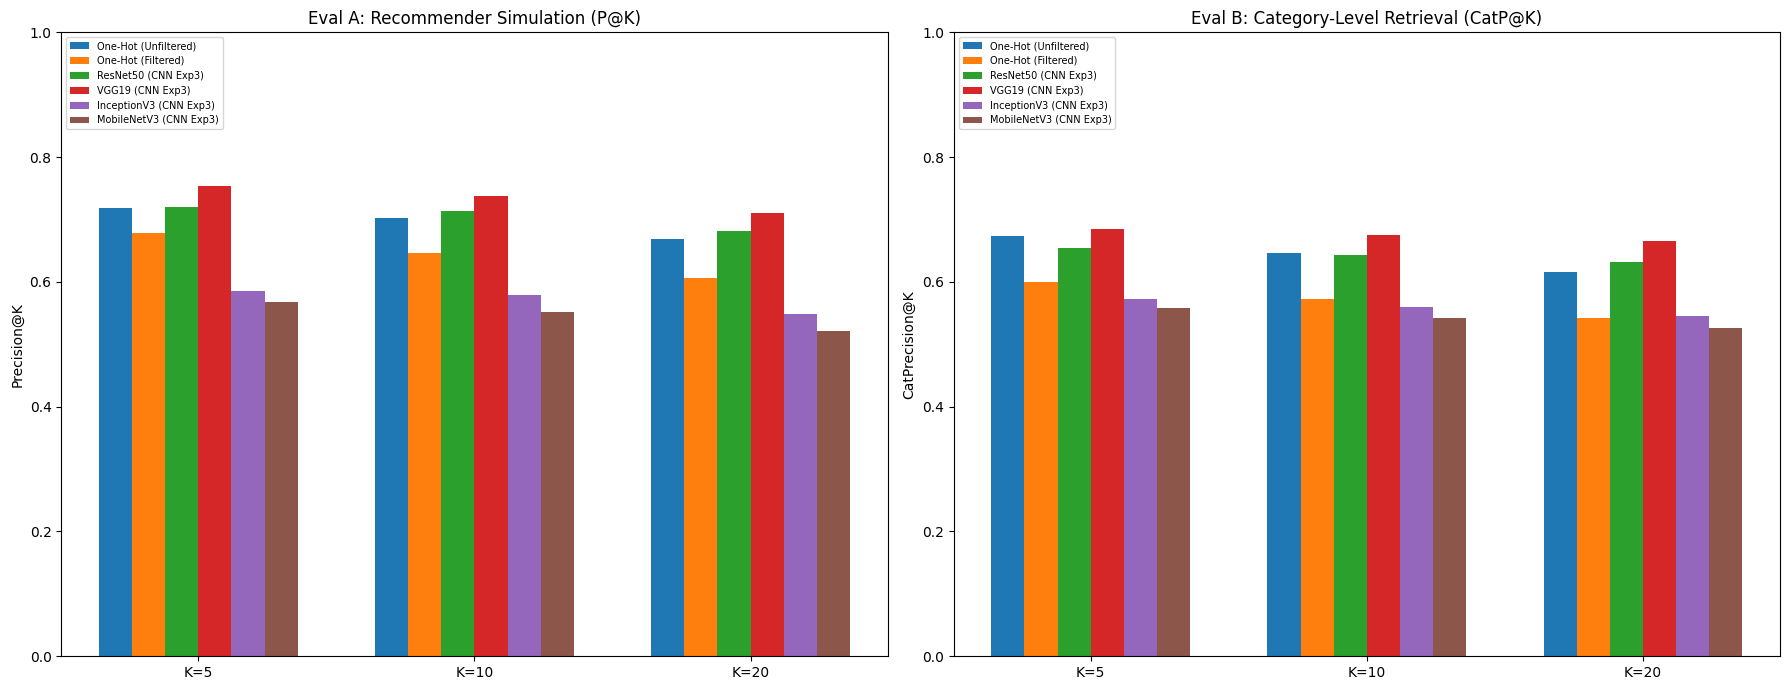

Saved: onehot_vs_cnn_comparison.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
all_m = list(sim.keys())
x = np.arange(len(K_VALUES)); w = 0.12
ax1 = axes[0]
for i, method in enumerate(all_m):
    vals = [sim[method][k]['precision'] for k in K_VALUES]
    ax1.bar(x+i*w, vals, w, label=method)
ax1.set_xticks(x+w*(len(all_m)-1)/2); ax1.set_xticklabels([f'K={k}' for k in K_VALUES])
ax1.set_ylabel('Precision@K'); ax1.set_title('Eval A: Recommender Simulation (P@K)')
ax1.legend(fontsize=7, loc='upper left'); ax1.set_ylim(0, 1.0)

retr_m = list(retr.keys())
ax2 = axes[1]
for i, method in enumerate(retr_m):
    vals = [retr[method][k] for k in K_VALUES]
    ax2.bar(x+i*w, vals, w, label=method)
ax2.set_xticks(x+w*(len(retr_m)-1)/2); ax2.set_xticklabels([f'K={k}' for k in K_VALUES])
ax2.set_ylabel('CatPrecision@K'); ax2.set_title('Eval B: Category-Level Retrieval (CatP@K)')
ax2.legend(fontsize=7, loc='upper left'); ax2.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, 'onehot_vs_cnn_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: onehot_vs_cnn_comparison.png')

In [18]:
# ── Old vs New Filter Comparison ────────────────────────────────────
OLD_KW = {'jumpsuit','romper','sweatshirt','shorts','pants','blouse','hoodie','dress'}
old_leaky = {i for i, a in enumerate(attr_names) if set(a.lower().replace('-',' ').replace('_',' ').split()) & OLD_KW}
new_only = leaky_indices - old_leaky

print('='*70)
print('  OLD HARDCODED vs NEW STATISTICAL FILTER')
print('='*70)
print(f'  Old filter removed : {len(old_leaky)} attrs')
print(f'  New filter removed : {len(leaky_indices)} attrs (>{DOMINANCE_THRESHOLD:.0%})')
print(f'  Both caught        : {len(old_leaky & leaky_indices)}')
print(f'  NEW detections    : +{len(new_only)} additional leaky attrs')
if new_only:
    print(f'\n  Leaky attributes OLD filter MISSED:')
    for idx in sorted(new_only):
        r = df_report[df_report['attr_index']==idx].iloc[0]
        print(f'    - {r["attr_name"]:<20} {r["dominance_pct"]:.1%} -> {r["dominant_category"]}')

print('\n'+'='*70)
print('  OUTPUT FILES:')
print(f'    1. evaluation/leakage_report.csv')
print(f'    2. evaluation/onehot_filtered_matrix.npy')
print(f'    3. evaluation/onehot_unfiltered_matrix.npy')
print(f'    4. evaluation/onehot_item_index.csv')
print(f'    5. evaluation/leakage_scan_distribution.png')
print(f'    6. evaluation/onehot_vs_cnn_comparison.png')
print(f'\n  Original list_attr_all.csv is UNTOUCHED.')
print('='*70)

  OLD HARDCODED vs NEW STATISTICAL FILTER
  Old filter removed : 8 attrs
  New filter removed : 13 attrs (>70%)
  Both caught        : 8
  NEW detections    : +5 additional leaky attrs

  Leaky attributes OLD filter MISSED:
    - bodycon              81.0% -> Dresses
    - peasant              77.1% -> Blouses_Shirts
    - notched              78.1% -> Jackets_Coats
    - light                100.0% -> Dresses
    - sweatpants           95.7% -> Pants

  OUTPUT FILES:
    1. evaluation/leakage_report.csv
    2. evaluation/onehot_filtered_matrix.npy
    3. evaluation/onehot_unfiltered_matrix.npy
    4. evaluation/onehot_item_index.csv
    5. evaluation/leakage_scan_distribution.png
    6. evaluation/onehot_vs_cnn_comparison.png

  Original list_attr_all.csv is UNTOUCHED.
